# Step 1: Data Cleaning & Exploratory Data Analysis (EDA)

**Dataset:** 541,909 raw transactions from a UK-based online retailer (Dec 2010 – Dec 2011).

**Notebook Scope:**
1. **Raw Data Ingestion & Inspection:** Load initial transactions and audit schema/missing values.
2. **Data Cleaning & Filtering:** Handle cancelled invoices, filter non-UK transactions, and remove invalid stock items.
3. **Exploratory Data Analysis (EDA):** Analyze revenue trends, purchasing patterns, top products, and customer behavior.
4. **Baseline RFM Construction:** Establish a traditional RFM baseline for feature engineering benchmarks.
5. **Clean Data Export:** Save refined dataset for downstream feature extraction.



## Set Up

In [17]:
%load_ext autoreload
%autoreload 2

# Import libraries
import sys
sys.path.append('../src')

from clustering_library import DataCleaner, DataVisualizer, compute_rfm
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Set up chart style
visualizer = DataVisualizer()

## Load Dataset

In [19]:
# Load the Online Retail dataset

data_path = "../data/raw/online_retail.xlsx"

# Initialise data cleaner and load data
cleaner = DataCleaner(data_path)
df = cleaner.load_data()

# Display first rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom


In [20]:
# Check basic dataset information
print("Dataset overview:")
print(f"- Size: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"- Missing values: {df.isnull().sum().sum():,}")
print(f"- Unique customers: {df['CustomerID'].nunique():,}")

df.info()

Dataset overview:
- Size: 541,909 rows x 8 columns
- Missing values: 136,534
- Unique customers: 4,372
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


## Data Cleaning & Preprocessing

**Cleaning Pipeline Steps:**

1. **Feature Engineering (Total Price):** Compute `TotalPrice` column (`Quantity` × `UnitPrice`).
2. **Cancellation Filtering:** Remove cancelled transactions (invoices starting with `'C'`).
3. **Geographic Filtering:** Filter dataset to retain UK-based customers only.
4. **Identity Validation:** Drop records with missing `CustomerID` to ensure customer-level attribution.
5. **Anomaly Removal:** Exclude invalid records with non-positive `Quantity` or `UnitPrice` ($\le 0$).

In [21]:
# Clean the data
df_uk = cleaner.clean_data()

# Create time features for analysis
cleaner.create_time_features()

print("Data cleaning results:")
print(f"- Raw data: {df.shape[0]:,} transactions")
print(f"- Clean data: {df_uk.shape[0]:,} transactions")
print(f"- Removed: {df.shape[0] - df_uk.shape[0]:,} transactions ({((df.shape[0] - df_uk.shape[0])/df.shape[0]*100):.1f}%)")
print(f"- UK customers: {df_uk['CustomerID'].nunique():,}")

df_uk.head()

Data cleaning results:
- Raw data: 541,909 transactions
- Clean data: 354,321 transactions
- Removed: 187,588 transactions (34.6%)
- UK customers: 3,920


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,HourOfDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom,15.30,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom,22.00,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8


## Exploratory Data Analysis (EDA)

Following data sanitization, we analyze underlying transaction trends, revenue dynamics, and customer purchasing behaviors.




### Revenue Trends Over Time

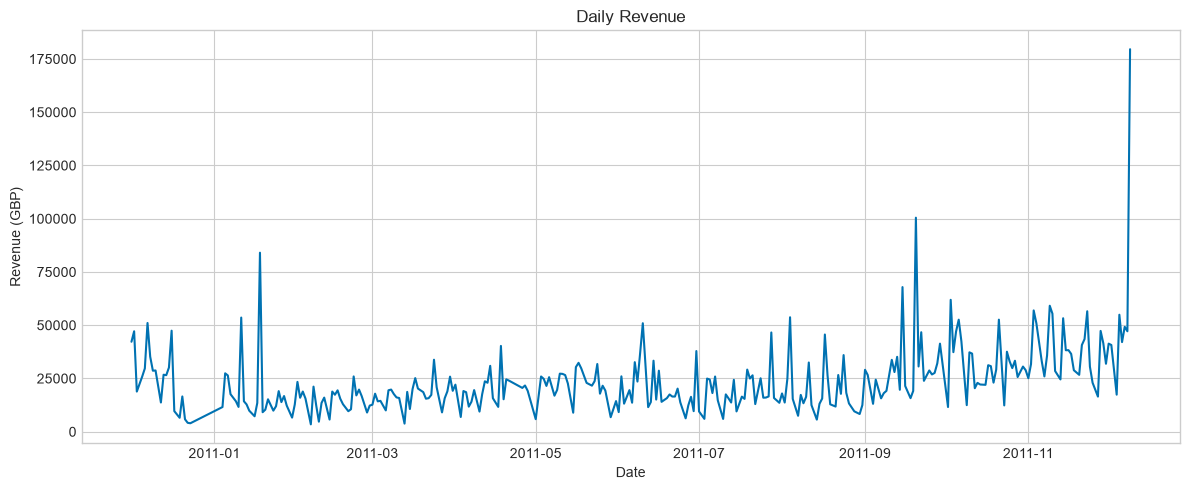

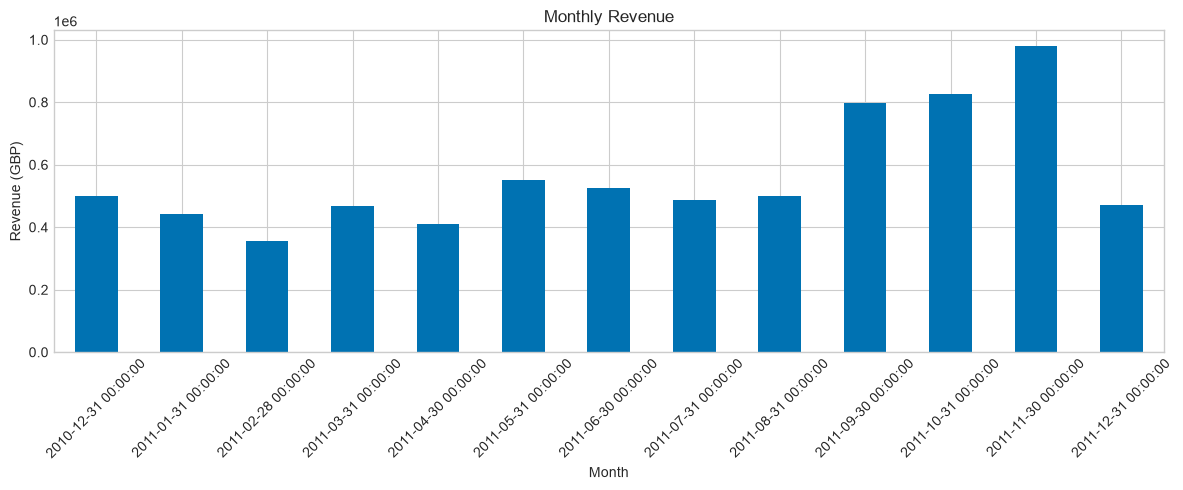

In [22]:
# Plot revenue over time
visualizer.plot_revenue_over_time(df_uk)

### Mẫu thời gian mua hàng

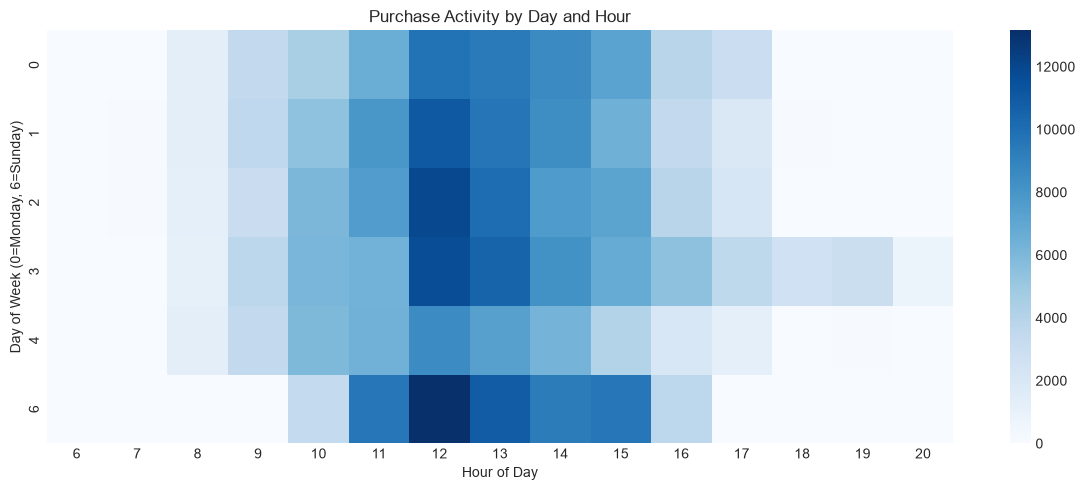

In [23]:
# Analyse purchase time patterns
visualizer.plot_time_patterns(df_uk)

## Product Analysis

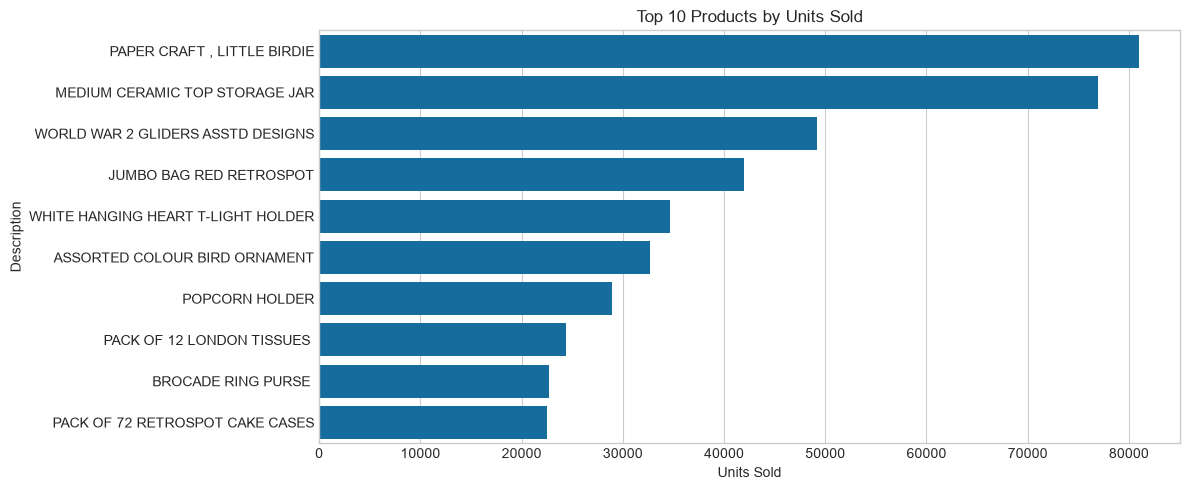

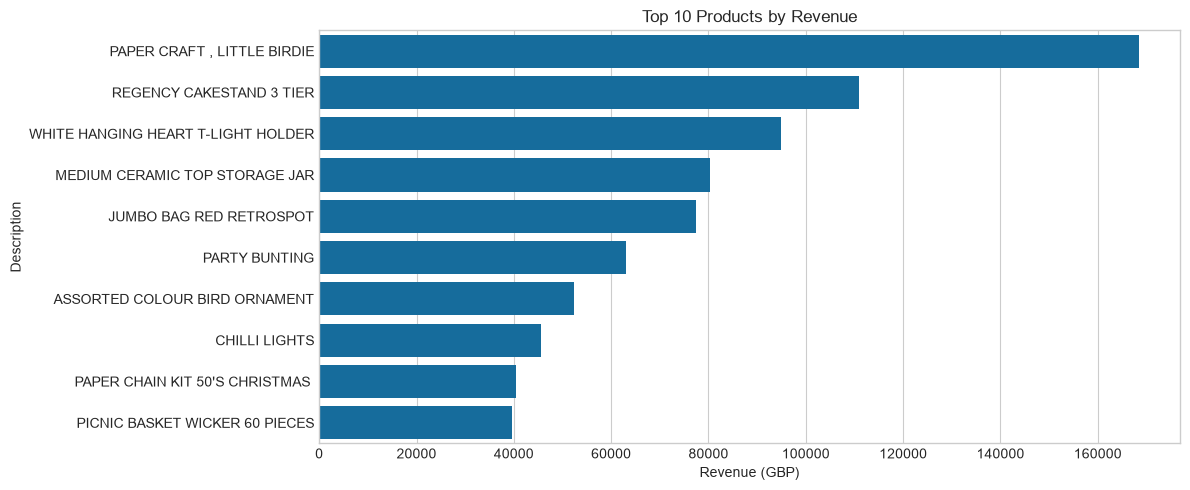

In [24]:
# Top product analysis
visualizer.plot_product_analysis(df_uk)

## Customer Behaviour Analysis

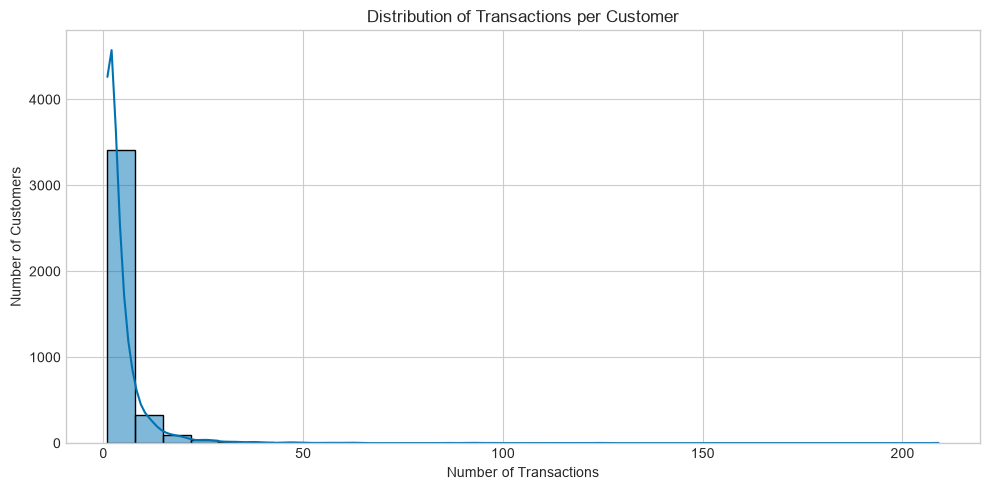

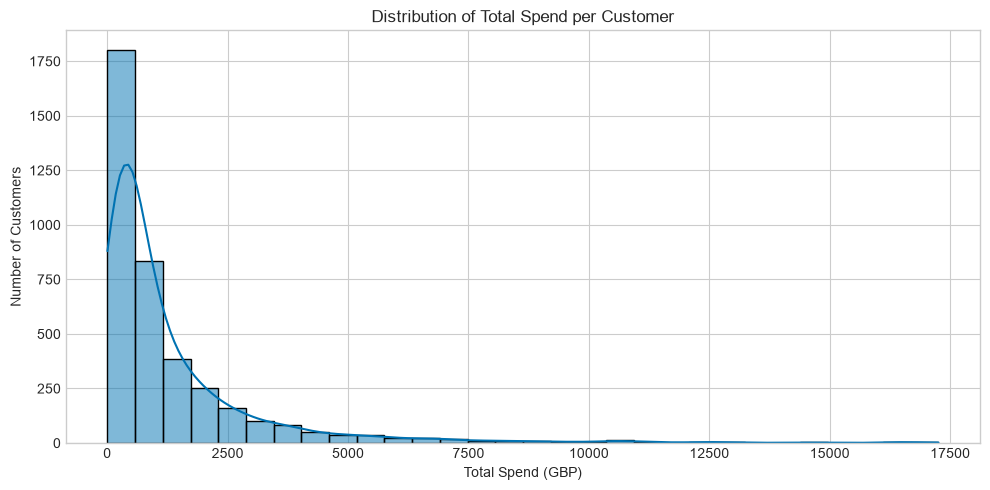

In [25]:
# Customer behaviour distribution analysis
visualizer.plot_customer_distribution(df_uk)

In [26]:
# Customer spending analysis
spend_per_customer = df_uk.groupby("CustomerID")["TotalPrice"].sum()
transactions_per_customer = df_uk.groupby("CustomerID")["InvoiceNo"].nunique()

print("Customer behaviour analysis:")
print(f"- Average spend: £{spend_per_customer.mean():.2f}")
print(f"- Median spend: £{spend_per_customer.median():.2f}")
print(f"- Average transactions: {transactions_per_customer.mean():.1f}")

spend_per_customer.describe()

Customer behaviour analysis:
- Average spend: £1864.39
- Median spend: £652.28
- Average transactions: 4.2


count      3920.000000
mean       1864.385601
std        7482.817477
min           3.750000
25%         300.280000
50%         652.280000
75%        1576.585000
max      259657.300000
Name: TotalPrice, dtype: float64

### Baseline RFM Analysis Preparation

We aggregate the cleaned transactional data to construct a traditional baseline RFM (Recency, Frequency, Monetary) model at the customer level:

* **Recency (R):** Days since the customer's most recent purchase.
* **Frequency (F):** Total number of distinct completed transactions/orders.
* **Monetary (M):** Total monetary value spent across all orders.

In [27]:
# Calculate RFM metrics (Recency, Frequency, Monetary)
rfm_data = compute_rfm(df_uk).set_index('CustomerID')

print("RFM Analysis:")
print(f"- Mean Recency: {rfm_data['Recency'].mean():.0f} days")
print(f"- Mean Frequency: {rfm_data['Frequency'].mean():.1f} transactions")
print(f"- Mean Monetary: £{rfm_data['Monetary'].mean():.2f}")

rfm_data.head(10)

RFM Analysis:
- Mean Recency: 92 days
- Mean Frequency: 4.2 transactions
- Mean Monetary: £1864.39


,Recency,Frequency,Monetary
CustomerID,,,
012346,326,1,77183.60
012747,2,11,4196.01
012748,1,209,33719.73
012749,4,5,4090.88
012820,3,4,942.34
012821,214,1,92.72
012822,71,2,948.88
012823,75,5,1759.50
012824,60,1,397.12


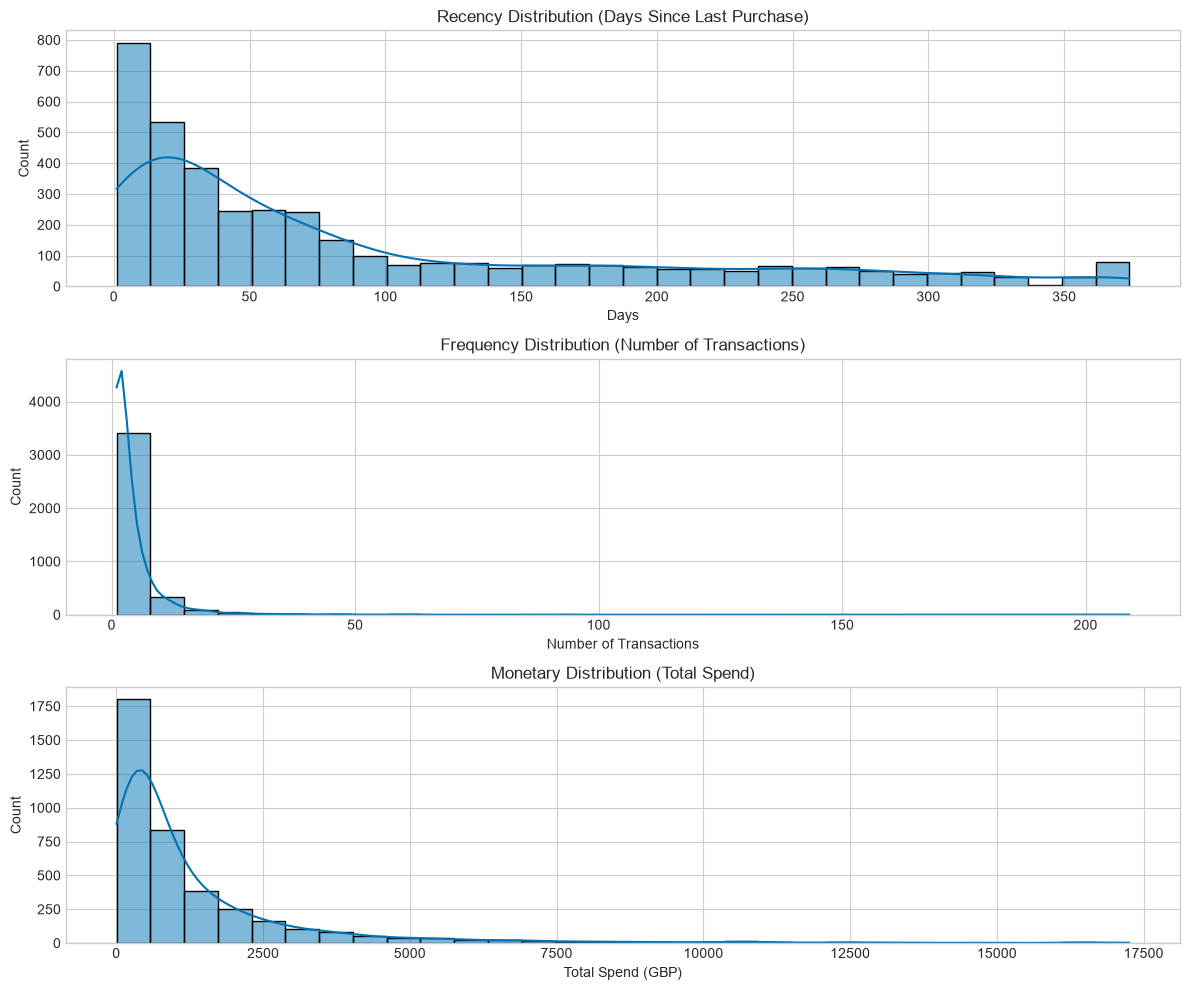

In [28]:
# Visualise RFM distributions
visualizer.plot_rfm_analysis(rfm_data)

## Save Cleaned Data

In [29]:
# Save cleaned data (sandbox by default — never overwrites canonical artefacts)
cleaner.save_cleaned_data(wpath("processed"))

print("Data saved successfully:")
print("- File: cleaned_uk_data.csv")
print(f"- Size: {df_uk.shape[0]:,} rows")
print("- Ready for feature engineering")

Data saved successfully:
- File: cleaned_uk_data.csv
- Size: 354,321 rows
- Ready for feature engineering


## Notebook 01 Summary

| Metric | Output / Findings |
| :--- | :--- |
| **Raw Data Volume** | 541,909 transactions |
| **Cleaned Data Volume** | **354,321 transactions** across **3,920 UK unique customers** |
| **Filtered Anomalies** | **187,588 records (34.6%)** removed (cancellations, non-UK, missing CustomerID, non-positive qty/price) |
| **Revenue Dynamics** | Steady upward trend throughout 2011, peaking in November (Q4 seasonal surge) |
| **Purchasing Timing** | Weekdays during 10:00 – 15:00 peak window, with secondary activity on Sunday midday |
| **Monetary Metrics** | Median spend: **£652** / Mean spend: **£1,864** (highly right-skewed distribution) |

**Next Step:** [`02_feature_engineering.ipynb`](02_feature_engineering.ipynb) — Engineering 20 advanced behavioral features.